## 岭回归（Ridge Regression）
#### **数学原理**
我们在做普通的线性回归时，时常会遇到模型**过拟合**，导致预测结果并不尽人意的情况，这时我们就可以考虑在原先的RSS损失函数后面再加上一项限制系数的惩罚项,得到新的损失函数，表达式如下所示（表达式默认都省略偏置项）

$$J(w) = \sum_{i} (y_i - \hat{y}_i)^2 + \alpha \sum_{j} w_j^2$$


其中,新添加的 $\alpha \sum_{j} w_j^2$ 称为**L2正则化项**，目的在于限制系数的大小，化解过拟合的情况

将其化为矩阵形式：
$$J(w) = (y - X w)^T (y - X w) + \alpha w^T w$$
令 $\nabla J(w) = 0$ 解得其解析解为：
$$\hat{w}_{ridge} = (X^T X - \alpha I)^{-1} X^T y$$

> 当然，和线性回归一样，数据量和特征数较小时，我们可能会考虑用表达式求解 $\hat{w}$ ；一旦数据量或特征数较大，我们仍然会使用机器学习的方法来求数值解
#### **$\alpha$(正则化强度)**
$\alpha$是用来控制L2正则化项的惩罚力度，$\alpha$ 越大，惩罚力度越强

当 $\alpha = 0$ 时,岭回归将退化为线性回归

问题：

此例中，我们将使用 sklearn 中内置的 diabetes 数据集，用于预测糖尿病患者一年后的疾病进展。

包含10个基线变量，如年龄、BMI、血压等，不同特征间存在多重共线性

In [17]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### **1.导入并观察数据集的基本情况**

In [18]:
diabetes = load_diabetes()
print(diabetes['DESCR'])
df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
print(df)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### **2.划分训练集和验证集**

In [19]:
X = diabetes.data
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### **3.数据进行标准化处理**
在岭回归中，由于系数的大小天然与其对应的特征值的尺度相关，而 L2 正则化项的惩罚力度确实统一的，所以数据的标准化处理仍然是必要的

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.训练模型并进行预测**
关于岭回归，其函数有几个常用的参数值得我们了解
| 参数名 | 默认值 | 作用 | 使用建议 |
|---|---|---|---|
|`alpha`| 1.0 | 控制正则化强度 | **最核心参数**,太小接近线性回归，太大欠拟合。用 RidgeCV 自动挑最优值 |
| `fit_intercept` | True | 是否拟合偏置项 | 若数据已手动中心化，则可设为 `False` |
| `copy_x` | True | 是否复制输入数据 x | 内存无法支持再复制一份数据，可设为 `False` |
| `solver` | auto | 求解算法选择 | 通常保持默认就行 |
| `max_iter` | None | 迭代求解器的最大迭代次数 | 如若手动设置最大次数，出现收敛警告时增大该值 |
| `tol` | 0.001 | 迭代收敛容差 | 如果想要更高的精度可手动设置更小的值 |

In [21]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}
grid_searcher = GridSearchCV(estimator = ridge,
                             param_grid = param_grid,
                             cv = 5,    #做 5 次交叉验证
                             scoring = 'r2',
                             n_jobs = -1    #使用所有 cpu 核心进行并行运算
                             )

grid_searcher.fit(X_train, y_train)
print(f"最佳参数：{grid_searcher.best_params_}")
print(f"最佳交叉验证分数：{grid_searcher.best_score_}")

best_ridge = grid_searcher.best_estimator_
y_pred = best_ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

最佳参数：{'alpha': 10}
最佳交叉验证分数：0.5268018341894608


3429.236228387488

### **5.评估预测效果**
回归问题的评估指标与分类不同，以下是三个最常用的指标：
| 指标 | 含义 | 什么时候重点看 |
|------|------|-------------|
| **RMSE** | 均方根误差，预测值与真实值偏差的平方取平均再开根 | 默认首选，和大误差敏感，和 y 同单位 |
| **MAE** | 平均绝对误差，预测值与真实值偏差的绝对值取平均 | 数据中有异常值时比 RMSE 更可靠 |
| **R²** | 模型解释了目标变量多少比例的方差，取值范围 [0, 1] | 看模型的整体拟合程度，越接近 1 越好 |

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}  (越小越好，和 y 同单位)")
print(f"MAE:  {mae:.2f}  (越小越好，对异常值不敏感)")
print(f"R²:   {r2:.3f}  (越接近 1 越好)")

RMSE: 58.56  (越小越好，和 y 同单位)
MAE:  46.12  (越小越好，对异常值不敏感)
R²:   0.331  (越接近 1 越好)


### **6.预测结果可视化**

#### 6.1 预测值 vs 真实值 + 残差分布
左图：点越接近红色对角线说明预测越准。右图：好的残差图应围绕 0 线随机分布，没有明显的喇叭形或曲线趋势。

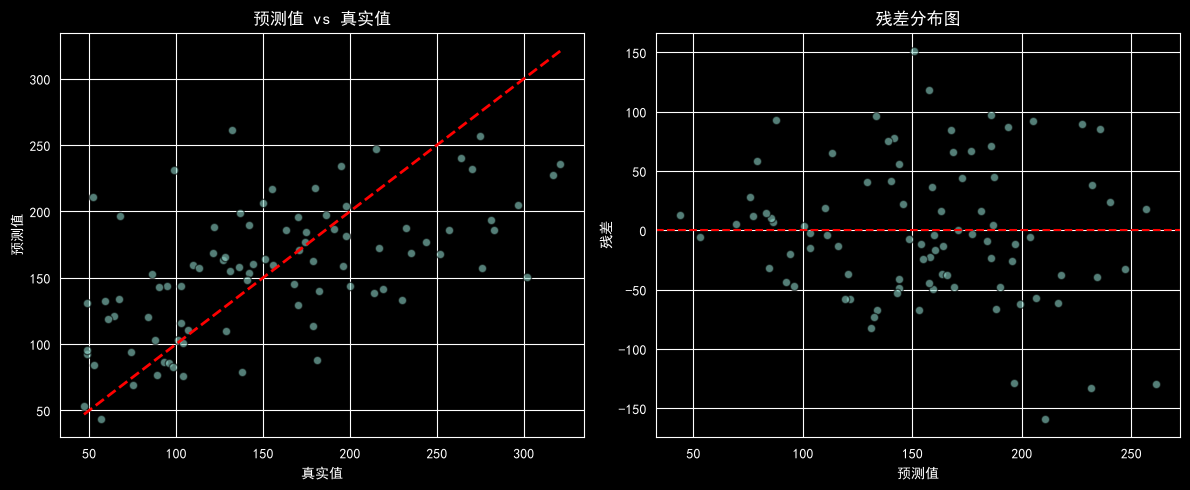

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：预测值 vs 真实值
ax1.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('真实值')
ax1.set_ylabel('预测值')
ax1.set_title('预测值 vs 真实值')

# 右图：残差分布
ax2.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('预测值')
ax2.set_ylabel('残差')
ax2.set_title('残差分布图')

plt.tight_layout()
plt.savefig('ridge_pred_residual.png', dpi=200, bbox_inches='tight')
plt.show()

#### 6.2 Alpha 路径图——系数收缩过程
这是岭回归最有辨识度的图：横轴是 α（正则化强度），纵轴是每个特征的系数值。α 越大，系数越被"压缩"到接近 0，可以直观看到哪些特征抗压缩（重要），哪些最先归零（噪音）。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

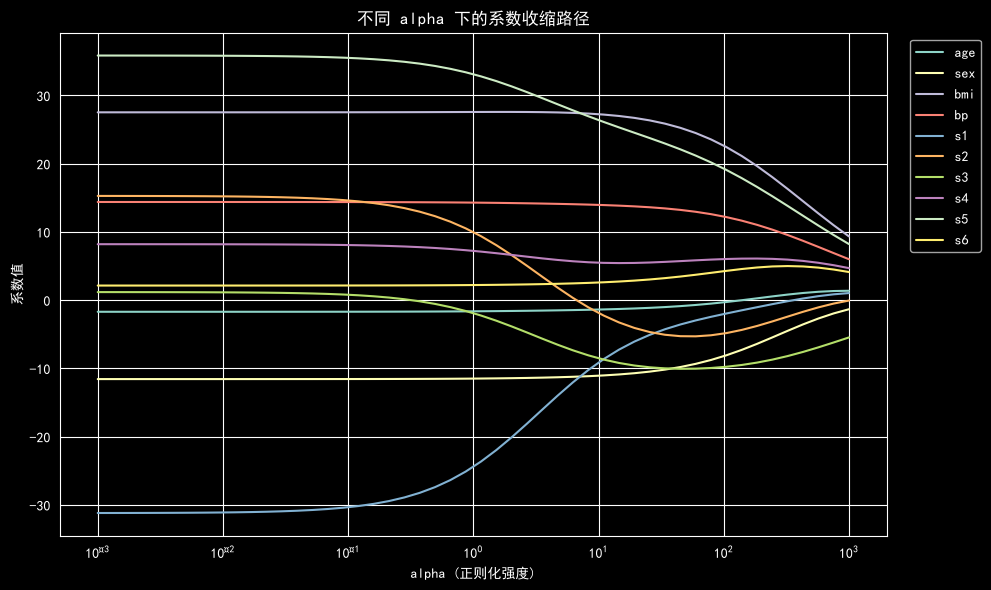

In [24]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 3, 50)  # 0.001 到 1000，对数均匀取 50 个点
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('alpha (正则化强度)')
plt.ylabel('系数值')
plt.title('不同 alpha 下的系数收缩路径')
plt.legend(diabetes.feature_names, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ridge_alpha_path.png', dpi=200, bbox_inches='tight')
plt.show()